# Hands-On Part 2 - Modern Deep RL
- using the gymnasium CartPole
    - ![CartPole](https://gymnasium.farama.org/_images/cart_pole.gif)
        - Credit: image from https://gymnasium.farama.org 

## Installation and Imports

In [1]:
!pip install gymnasium stable-baselines3

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
import torch
import sys

import time
import pygame 

print("=== Reinforcement Learning Setup ===")
print("Python version:", sys.version.split()[0])
print("Gymnasium version:", gym.__version__)
print("Stable-Baselines3: ✓ Imported successfully")
print("PyTorch version:", torch.__version__)
print("NumPy version:", np.__version__)
print("\n All packages loaded! Ready for Deep RL!")

=== Reinforcement Learning Setup ===
Python version: 3.11.11
Gymnasium version: 1.2.1
Stable-Baselines3: ✓ Imported successfully
PyTorch version: 2.6.0
NumPy version: 2.1.3

 All packages loaded! Ready for Deep RL!


## Environment Setup and Analysis

In [3]:
env = gym.make('CartPole-v1')

print("=== Environment Analysis ===")
print("Action Space:", env.action_space)
print("Observation Space:", env.observation_space)
print("Observation Space Shape:", env.observation_space.shape)
print("Observation Space Low bounds:", env.observation_space.low)
print("Observation Space High bounds:", env.observation_space.high)

# Let's see what a random episode looks like
state, info = env.reset()
print(f"\nInitial state: {state}")
print("State components: [cart_position, cart_velocity, pole_angle, pole_angular_velocity]")

# Test a random action
action = env.action_space.sample()
print(f"Random action: {action} (0=left, 1=right)")
next_state, reward, terminated, truncated, info = env.step(action)
print(f"Next state: {next_state}")
print(f"Reward: {reward}, Terminated: {terminated}, Truncated: {truncated}")
env.close()

=== Environment Analysis ===
Action Space: Discrete(2)
Observation Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Observation Space Shape: (4,)
Observation Space Low bounds: [-4.8               -inf -0.41887903        -inf]
Observation Space High bounds: [4.8               inf 0.41887903        inf]

Initial state: [-0.04789536 -0.04491596 -0.04066084 -0.03111153]
State components: [cart_position, cart_velocity, pole_angle, pole_angular_velocity]
Random action: 1 (0=left, 1=right)
Next state: [-0.04879368  0.1507648  -0.04128307 -0.33634102]
Reward: 1.0, Terminated: False, Truncated: False


## Understanding the Problem

In [4]:
print("=== CartPole Problem Details ===")
print("Goal: Balance a pole on a moving cart for as long as possible")
print("State Space (4 dimensions):")
print("  1. Cart Position: ~ -4.8 to +4.8")
print("  2. Cart Velocity: Continuous")
print("  3. Pole Angle: ~ -0.418 rad (-24°) to +0.418 rad (+24°)") 
print("  4. Pole Angular Velocity: Continuous")
print("\nEpisode ends when:")
print("  - Pole angle > ±12° from vertical")
print("  - Cart moves > ±2.4 from center")
print("  - 500 timesteps reached (truncation)")
print("\nReward: +1 for every timestep the pole remains balanced")

=== CartPole Problem Details ===
Goal: Balance a pole on a moving cart for as long as possible
State Space (4 dimensions):
  1. Cart Position: ~ -4.8 to +4.8
  2. Cart Velocity: Continuous
  3. Pole Angle: ~ -0.418 rad (-24°) to +0.418 rad (+24°)
  4. Pole Angular Velocity: Continuous

Episode ends when:
  - Pole angle > ±12° from vertical
  - Cart moves > ±2.4 from center
  - 500 timesteps reached (truncation)

Reward: +1 for every timestep the pole remains balanced


## Create and Understand the DQN Agent

In [5]:
# Cell 4: Create and Understand the DQN Agent
print("=== Creating DQN Agent ===")

# Create a monitored environment for tracking progress
env = Monitor(gym.make('CartPole-v1'))

# Initialize the DQN agent
model = DQN(
    'MlpPolicy',           # Multi-layer perceptron policy
    env,
    learning_rate=1e-3,
    buffer_size=10000,     # Experience replay buffer
    learning_starts=1000,  # Learn after collecting some experiences
    batch_size=64,         # Mini-batch size
    tau=1.0,               # Target network update rate
    gamma=0.99,            # Discount factor
    train_freq=4,          # Update model every 4 steps
    gradient_steps=1,      # Gradient steps per update
    target_update_interval=500,  # Update target network
    exploration_fraction=0.1,    # Exploration schedule
    exploration_initial_eps=1.0, # Start with high exploration
    exploration_final_eps=0.05,  # End with low exploration
    verbose=1              # Print training info
)

print("✅ DQN Agent created successfully!")
print("\nKey Components:")
print("1. 🧠 Neural Network: Approximates Q-values for continuous states")
print("2. 📚 Experience Replay: Stores past experiences for stable learning")
print("3. 🎯 Target Network: Separate network for stable Q-targets") 
print("4. 🔍 ϵ-greedy Exploration: Balances exploration vs exploitation")

=== Creating DQN Agent ===
Using cpu device
Wrapping the env in a DummyVecEnv.
✅ DQN Agent created successfully!

Key Components:
1. 🧠 Neural Network: Approximates Q-values for continuous states
2. 📚 Experience Replay: Stores past experiences for stable learning
3. 🎯 Target Network: Separate network for stable Q-targets
4. 🔍 ϵ-greedy Exploration: Balances exploration vs exploitation


## Training the Agent

In [6]:
print("=== Starting Training ===")
print("This will train for 10,000 timesteps (~20-50 episodes)")
print("Watch the episode length increase as the agent learns!")

# Train the model
model.learn(total_timesteps=10000, log_interval=10)

print("\n=== Training Complete ===")
print("🎉 The agent has learned a policy to balance the pole!")

=== Starting Training ===
This will train for 10,000 timesteps (~20-50 episodes)
Watch the episode length increase as the agent learns!
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 19.4     |
|    ep_rew_mean      | 19.4     |
|    exploration_rate | 0.816    |
| time/               |          |
|    episodes         | 10       |
|    fps              | 10897    |
|    time_elapsed     | 0        |
|    total_timesteps  | 194      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 23.9     |
|    ep_rew_mean      | 23.9     |
|    exploration_rate | 0.545    |
| time/               |          |
|    episodes         | 20       |
|    fps              | 12067    |
|    time_elapsed     | 0        |
|    total_timesteps  | 479      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 

## Visualize Training Progress

=== Training Results ===


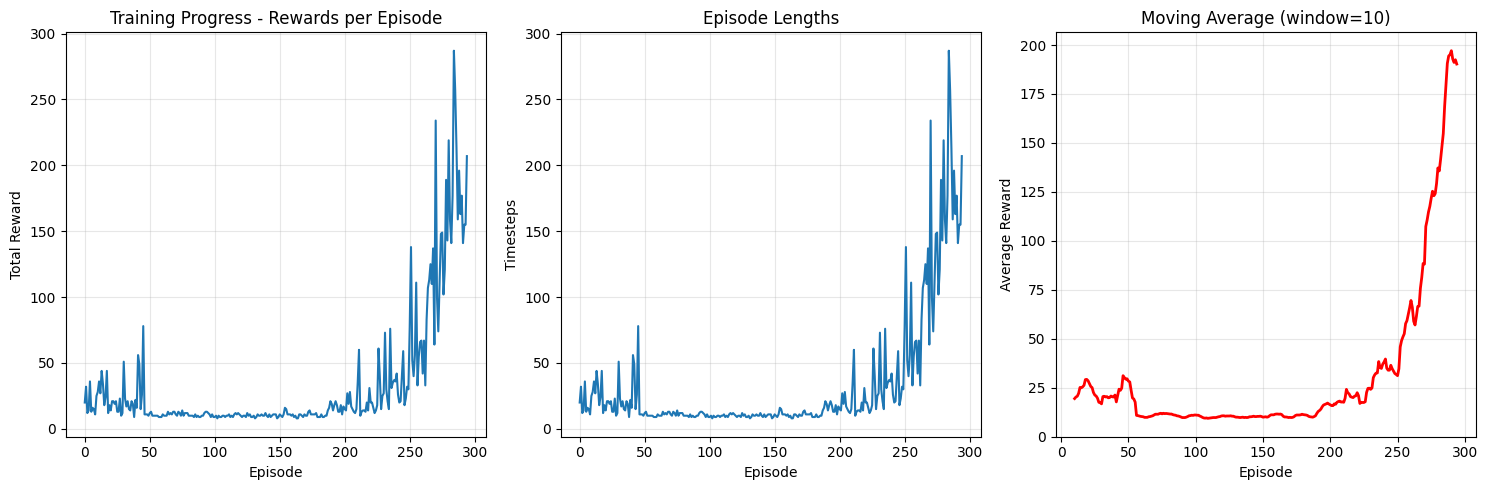

Final performance: 182.3 average reward (last 10 episodes)
Best episode: 287.0 timesteps
Total training episodes: 295


In [7]:
print("=== Training Results ===")

# Get the monitoring results
results = env.get_episode_rewards()
episode_lengths = env.get_episode_lengths()

if len(results) > 0:
    plt.figure(figsize=(15, 5))

    # Plot 1: Rewards over episodes
    plt.subplot(1, 3, 1)
    plt.plot(results)
    plt.title('Training Progress - Rewards per Episode')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.grid(True, alpha=0.3)

    # Plot 2: Episode lengths
    plt.subplot(1, 3, 2)
    plt.plot(episode_lengths)
    plt.title('Episode Lengths')
    plt.xlabel('Episode')
    plt.ylabel('Timesteps')
    plt.grid(True, alpha=0.3)

    # Plot 3: Moving average (smoother view of progress)
    plt.subplot(1, 3, 3)
    window = min(10, len(results) // 4)
    if window > 0 and len(results) > window:
        moving_avg = [np.mean(results[i-window:i]) for i in range(window, len(results))]
        plt.plot(range(window, len(results)), moving_avg, 'r-', linewidth=2)
        plt.title(f'Moving Average (window={window})')
        plt.xlabel('Episode')
        plt.ylabel('Average Reward')
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    last_10 = results[-10:] if len(results) >= 10 else results
    print(f"Final performance: {np.mean(last_10):.1f} average reward (last {len(last_10)} episodes)")
    print(f"Best episode: {np.max(results)} timesteps")
    print(f"Total training episodes: {len(results)}")
else:
    print("No training data collected - check for errors")

## Evaluate the Trained Agent

In [8]:
# Cell 7: Evaluate the Trained Agent
print("=== Evaluating Trained Agent ===")

# Create a new environment for evaluation
eval_env = gym.make('CartPole-v1')

# Evaluate the agent
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10, deterministic=True)

print(f"Evaluation Results (10 episodes):")
print(f"Mean reward: {mean_reward:.2f} ± {std_reward:.2f}")

# Maximum possible is 500 (environment truncation limit)
if mean_reward > 450:
    print("🎉 Excellent! Agent has nearly mastered the environment!")
elif mean_reward > 300:
    print("✅ Good performance! Agent can balance the pole well.")
elif mean_reward > 100:
    print("📈 Learning progress made, but room for improvement.")
else:
    print("🔄 May need more training time.")

eval_env.close()

=== Evaluating Trained Agent ===


/Users/jasonlau/.pyenv/versions/3.11.11/envs/deeplearn/lib/python3.11/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Evaluation Results (10 episodes):
Mean reward: 186.70 ± 61.75
📈 Learning progress made, but room for improvement.


## Understanding what the Agent Learned

In [9]:
print("=== Analyzing the Learned Policy ===")

# Test the agent on some specific states
test_states = [
    [0.0, 0.0, 0.0, 0.0],           # Perfectly balanced
    [0.0, 0.0, 0.1, 0.0],           # Pole slightly right
    [0.0, 0.0, -0.1, 0.0],          # Pole slightly left  
    [0.5, 0.0, 0.05, 0.0],          # Right position, pole right
    [-0.5, 0.0, -0.05, 0.0],        # Left position, pole left
]

print("State -> [cart_pos, cart_vel, pole_angle, pole_vel] -> Action")
print("-" * 60)

for state_vec in test_states:
    state_array = np.array(state_vec, dtype=np.float32)
    action, _ = model.predict(state_array, deterministic=True)
    action_str = "RIGHT" if action == 1 else "LEFT"
    
    print(f"[{state_vec[0]:5.2f}, {state_vec[1]:5.2f}, {state_vec[2]:5.2f}, {state_vec[3]:5.2f}] -> {action_str}")

print("\n🤔 The agent has learned to push LEFT when the pole leans LEFT")
print("   and push RIGHT when the pole leans RIGHT - just like a human would!")

=== Analyzing the Learned Policy ===
State -> [cart_pos, cart_vel, pole_angle, pole_vel] -> Action
------------------------------------------------------------
[ 0.00,  0.00,  0.00,  0.00] -> LEFT
[ 0.00,  0.00,  0.10,  0.00] -> RIGHT
[ 0.00,  0.00, -0.10,  0.00] -> LEFT
[ 0.50,  0.00,  0.05,  0.00] -> LEFT
[-0.50,  0.00, -0.05,  0.00] -> RIGHT

🤔 The agent has learned to push LEFT when the pole leans LEFT
   and push RIGHT when the pole leans RIGHT - just like a human would!


## Watch the Trained Agent in Action!

In [ ]:
print("=== Demo: Trained Agent Balancing the Pole ===")

try:
    # try GUI render
    env = gym.make('CartPole-v1', render_mode='human')
    state, info = env.reset()
    total_reward = 0

    try:
        for step in range(500):  # Max episode length
            action, _states = model.predict(state, deterministic=True)
            state, reward, terminated, truncated, info = env.step(action)
            total_reward += reward

            # Pump pygame events so the window remains responsive and close button works
            try:
                for ev in pygame.event.get():
                    if ev.type == pygame.QUIT:
                        raise KeyboardInterrupt("Window closed by user")
            except Exception:
                # if pygame isn't available or env doesn't use it, ignore
                pass

            # small sleep to avoid hogging CPU / make window responsive
            time.sleep(0.01)

            if terminated or truncated:
                print(f"Episode ended after {step + 1} timesteps")
                break

    except KeyboardInterrupt as e:
        print(f"Rendering interrupted: {e}")

    finally:
        # always attempt to close/cleanup
        try:
            env.close()
        except Exception:
            pass
        try:
            pygame.display.quit()
            pygame.quit()
        except Exception:
            pass

    print(f"Total reward: {total_reward}")

except Exception as e:
    # fallback for headless / Colab / unsupported envs
    print(f"Note: Rendering not available in this environment: {e}")
    print("The agent is still trained and functional! 🎯")
    print("\nText-based demo:")
    eval_env = gym.make('CartPole-v1')
    state, info = eval_env.reset()
    total_reward = 0

    for step in range(100):  # Show first 100 steps
        action, _states = model.predict(state, deterministic=True)
        state, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward

        if step < 3:  # Show first few actions
            action_str = "RIGHT" if action == 1 else "LEFT"
            print(f"Step {step}: Action={action_str}, Reward={reward}, State={state[:2]}")

        if terminated or truncated:
            print(f"Episode ended after {step + 1} timesteps")
            break

    print(f"Total reward: {total_reward}")
    eval_env.close()

=== Demo: Trained Agent Balancing the Pole ===
Episode ended after 149 timesteps
Total reward: 149.0


: 